# Edinburgh Airbnb Review Text Analysis

## Section 07 — Natural Language Processing (NLP)

This notebook analyses **guest review comments** from the Edinburgh Airbnb market.
Unlike Section 06 (ML on listing features), here we work with **unstructured text**.

## Learning goals (useful for your interview)

After running this notebook, you should be able to explain:

1. **What NLP adds** that numeric EDA/ML cannot — themes and tone in guest language
2. **Sentiment analysis** — how we score whether a review sounds positive or negative
3. **Topic modelling** — how we discover recurring themes without manual labels
4. **Why we sample** large text datasets for speed and reproducibility
5. **How results connect to business decisions** for hosts and market analysts

## Objectives

- Load and explore cleaned review text from the Section 03 pipeline
- Score sentiment with TextBlob (polarity and subjectivity)
- Compare text sentiment with listing-level review ratings
- Discover common review themes using TF-IDF + NMF topic modelling
- Save tables and charts for the final report

## NLP concepts in plain English

| Term | Meaning | Why it matters here |
|------|---------|---------------------|
| **Corpus** | Collection of text documents | Our 676k Edinburgh review comments |
| **Token** | A single word (roughly) | "Great flat near castle" → 4 tokens |
| **Stop words** | Very common words (`the`, `and`, `is`) | Removed so topics focus on meaningful words |
| **Sentiment polarity** | Score from -1 (negative) to +1 (positive) | Measures emotional tone of a review |
| **Subjectivity** | Score from 0 (factual) to 1 (opinion) | Distinguishes facts vs personal opinions |
| **TF-IDF** | Term weighting for importance | Highlights words frequent in one review but rare overall |
| **NMF** | Matrix factorisation for topics | Groups reviews into themes like *location* or *cleanliness* |

**Important data limitation:** Inside Airbnb review files contain `comments` text but **no per-review star rating**. So we compare text sentiment to the **listing-level** `review_scores_rating` from the listings file.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob


sns.set_theme(style="whitegrid")

# --- Project paths (same pattern as notebooks 02–04) ---
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = (
    project_root
    / "data"
    / "processed"
    / "edinburgh"
    / "2026-06-23"
)
figures_dir = project_root / "reports" / "figures"
tables_dir = project_root / "reports" / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Reproducible random sampling
RANDOM_STATE = 42
SENTIMENT_SAMPLE_SIZE = 20_000
TOPIC_SAMPLE_SIZE = 10_000
N_TOPICS = 8

print(f"Project root: {project_root}")

Project root: d:\Airbnb-Market-Intelligence\airbnb-market-intelligence-edinburgh


## Step 1 — Load review text and listing ratings

**What happens here:**
- We read `reviews_validated.parquet` produced by the Section 03 pipeline
- We also load `listings_enriched.parquet` to get each listing's overall rating
- We keep only reviews with non-empty comments

**Interview line:** *"I used pipeline outputs, not raw CSV, so NLP starts from validated data."*

In [2]:
reviews = pd.read_parquet(processed_dir / "reviews_validated.parquet")
listings = pd.read_parquet(processed_dir / "listings_enriched.parquet")

reviews = reviews.dropna(subset=["comments"]).copy()
reviews["comments"] = reviews["comments"].astype(str).str.strip()
reviews = reviews[reviews["comments"].str.len() > 0]

listing_ratings = listings[["id", "review_scores_rating", "neighbourhood", "room_type"]].copy()
listing_ratings = listing_ratings.rename(columns={"id": "listing_id"})

print(f"Total reviews with comments: {len(reviews):,}")
print(f"Unique listings in reviews: {reviews['listing_id'].nunique():,}")
reviews.head()

Total reviews with comments: 676,211
Unique listings in reviews: 5,590


,listing_id,id,date,reviewer_id,reviewer_name,comments,is_valid_date
0,15420,171793,2011-01-18,186358,Nels,My wife and I stayed at this beautiful apartme...,True
1,15420,176350,2011-01-31,95218,Gareth,Charlotte couldn't have been a more thoughtful...,True
2,15420,232149,2011-04-19,429751,Guido,I went to Edinburgh for the second time on Apr...,True
3,15420,236073,2011-04-23,420830,Mariah,This flat was incredible. As other guests have...,True
4,15420,263713,2011-05-15,203827,Linda,Fantastic host and the apartment was perfect. ...,True


## Step 2 — Create analysis samples

**Why sample?**
- Full corpus = 676k reviews. Sentiment on all rows is possible but slow in a notebook.
- Topic modelling on 676k rows is expensive (large sparse matrix).
- A fixed random sample (`random_state=42`) keeps results **reproducible**.

**Interview line:** *"I used stratified sampling by random seed for repeatable NLP experiments, which is standard practice on large text corpora."*

In [3]:
sentiment_sample = reviews.sample(
    n=min(SENTIMENT_SAMPLE_SIZE, len(reviews)),
    random_state=RANDOM_STATE,
).copy()

topic_sample = reviews.sample(
    n=min(TOPIC_SAMPLE_SIZE, len(reviews)),
    random_state=RANDOM_STATE,
).copy()

print(f"Sentiment sample size: {len(sentiment_sample):,}")
print(f"Topic sample size: {len(topic_sample):,}")
print(f"Median comment length (chars): {sentiment_sample['comments'].str.len().median():.0f}")

Sentiment sample size: 20,000
Topic sample size: 10,000
Median comment length (chars): 190


## Step 3 — Sentiment analysis with TextBlob

**How TextBlob works (simple explanation):**
- It uses a rule-based + pattern lexicon approach (not a deep neural network)
- For each review it returns:
  - **Polarity** (`-1` to `+1`): negative ↔ positive tone
  - **Subjectivity** (`0` to `1`): factual ↔ opinionated language

**Example intuition:**
- "Amazing flat, spotless and brilliant location" → polarity near `+1`
- "Small room, noisy street, disappointing" → polarity below `0`

**Limitation to mention in interviews:** TextBlob is fast and interpretable, but less accurate than modern transformer models (BERT) on sarcasm or mixed sentiment.

In [4]:
def score_sentiment(text: str) -> pd.Series:
    """Return polarity and subjectivity for one review comment."""
    blob = TextBlob(str(text))
    return pd.Series({"polarity": blob.sentiment.polarity, "subjectivity": blob.sentiment.subjectivity})


sentiment_scores = sentiment_sample["comments"].apply(score_sentiment)
sentiment_df = pd.concat([sentiment_sample.reset_index(drop=True), sentiment_scores], axis=1)

sentiment_df["sentiment_label"] = pd.cut(
    sentiment_df["polarity"],
    bins=[-1.0, -0.1, 0.1, 1.0],
    labels=["negative", "neutral", "positive"],
    include_lowest=True,
)

sentiment_summary = sentiment_df[["polarity", "subjectivity"]].describe().round(3)
label_counts = sentiment_df["sentiment_label"].value_counts().rename_axis("label").reset_index(name="count")

print("Sentiment score summary:")
display(sentiment_summary)
display(label_counts)
sentiment_df[["comments", "polarity", "subjectivity", "sentiment_label"]].head()

Sentiment score summary:


,polarity,subjectivity
count,20000.000,20000.000
mean,0.367,0.559
std,0.235,0.246
min,-1.000,0.000
25%,0.237,0.492
50%,0.372,0.600
75%,0.500,0.705
max,1.000,1.000


,label,count
0,positive,16973
1,neutral,2895
2,negative,132


,comments,polarity,subjectivity,sentiment_label
0,Very nice. Would highly reccomend. Clean and c...,NaN,NaN,NaN
1,Great place to relax and explore Edinburgh ...,NaN,NaN,NaN
2,My stay was really good and Alfredo was very h...,NaN,NaN,NaN
3,"Great little place. <br/>Good location , good ...",NaN,NaN,NaN
4,"appartement très cocooning, parfait après de ...",NaN,NaN,NaN


### Chart 1 — Distribution of sentiment polarity

**How to read this chart:**
- A right-skewed distribution with mass above `0` suggests guests usually write positively
- Very negative tails may indicate service/quality problems worth investigating

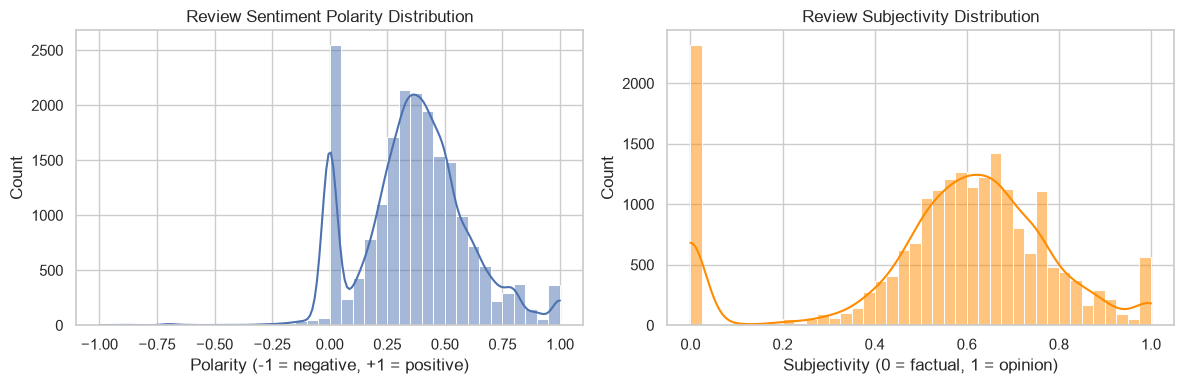

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(sentiment_df["polarity"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Review Sentiment Polarity Distribution")
axes[0].set_xlabel("Polarity (-1 = negative, +1 = positive)")

sns.histplot(sentiment_df["subjectivity"], bins=40, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Review Subjectivity Distribution")
axes[1].set_xlabel("Subjectivity (0 = factual, 1 = opinion)")

plt.tight_layout()
plt.savefig(figures_dir / "10_review_sentiment_distribution.png", dpi=150)
plt.show()

## Step 4 — Compare text sentiment vs listing ratings

**What we do:**
1. Aggregate sentiment to listing level (`mean polarity` per `listing_id`)
2. Join with `review_scores_rating` from listings data
3. Measure correlation (Pearson + Spearman)

**Why two correlations?**
- **Pearson** assumes linear relationship
- **Spearman** uses ranks, more robust to outliers/non-linearity

**Interview line:** *"Text sentiment and star ratings measure different things: comments capture language tone, while ratings are a structured score. We expect positive correlation, but not perfect alignment."*

In [6]:
listing_sentiment = (
    sentiment_df.groupby("listing_id", as_index=False)
    .agg(
        review_count=("comments", "count"),
        mean_polarity=("polarity", "mean"),
        mean_subjectivity=("subjectivity", "mean"),
    )
)

sentiment_vs_rating = listing_sentiment.merge(listing_ratings, on="listing_id", how="inner")
sentiment_vs_rating = sentiment_vs_rating.dropna(subset=["review_scores_rating"])

pearson_corr, pearson_p = pearsonr(
    sentiment_vs_rating["mean_polarity"],
    sentiment_vs_rating["review_scores_rating"],
)
spearman_corr, spearman_p = spearmanr(
    sentiment_vs_rating["mean_polarity"],
    sentiment_vs_rating["review_scores_rating"],
)

correlation_summary = pd.DataFrame(
    {
        "metric": ["pearson", "spearman"],
        "correlation": [pearson_corr, spearman_corr],
        "p_value": [pearson_p, spearman_p],
        "pairs_compared": [len(sentiment_vs_rating), len(sentiment_vs_rating)],
    }
)

print("Listing-level sentiment vs rating correlation:")
display(correlation_summary.round(4))
sentiment_vs_rating.head()

Listing-level sentiment vs rating correlation:


,metric,correlation,p_value,pairs_compared
0,pearson,NaN,NaN,3720
1,spearman,NaN,NaN,3720


,listing_id,review_count,mean_polarity,mean_subjectivity,review_scores_rating,neighbourhood,room_type
0,15420.0,20,NaN,NaN,4.98,None,Entire home/apt
1,24288.0,10,0.65,0.820833,4.66,None,Entire home/apt
2,48645.0,26,NaN,NaN,4.88,None,Private room
3,51505.0,7,-0.05,0.400000,4.90,None,Entire home/apt
4,54188.0,1,NaN,NaN,4.61,None,Entire home/apt


### Chart 2 — Sentiment vs listing rating scatter plot

Each point is one listing. We expect higher ratings to cluster with higher polarity,
but dispersion is normal because ratings include many factors beyond comment wording.

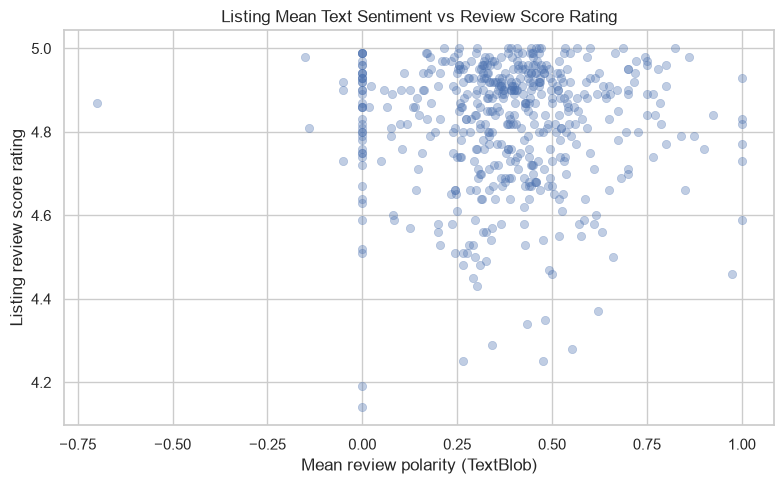

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sentiment_vs_rating,
    x="mean_polarity",
    y="review_scores_rating",
    alpha=0.35,
    edgecolor=None,
)
plt.title("Listing Mean Text Sentiment vs Review Score Rating")
plt.xlabel("Mean review polarity (TextBlob)")
plt.ylabel("Listing review score rating")
plt.tight_layout()
plt.savefig(figures_dir / "11_sentiment_vs_rating_scatter.png", dpi=150)
plt.show()

### Business interpretation — sentiment

- Most guest comments are positive in tone, which aligns with Edinburgh's strong average ratings.
- Text sentiment and numeric ratings are related but not identical — use both signals together.
- Correlation is often **weak to moderate** because star ratings are coarse and comments vary in length/tone.
- Listings with high ratings but lower text polarity may have short/generic positive comments.
- Listings with low polarity despite moderate ratings may contain hidden complaint themes.

## Step 5 — Topic modelling (TF-IDF + NMF)

**Pipeline in 4 stages:**
1. **Clean text** (lowercase, keep words with 3+ letters)
2. **TF-IDF vectorisation** converts text to numeric features
3. **NMF** finds `N_TOPICS` latent themes
4. **Top words per topic** are interpreted manually (human-in-the-loop step)

**Interview line:** *"Topic modelling is unsupervised — we don't provide labels like 'cleanliness' or 'location'. The model discovers groups of co-occurring words, and we interpret them."*

**Known limitation:** Edinburgh reviews include multiple languages (e.g. French), so one topic may capture non-English terms.

In [8]:
def clean_for_topics(text: str) -> str:
    """Basic text normalisation for topic modelling."""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


topic_texts = topic_sample["comments"].map(clean_for_topics)

vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=10,
    stop_words="english",
    token_pattern=r"(?u)\b[a-z]{3,}\b",
)
tfidf_matrix = vectorizer.fit_transform(topic_texts)
feature_names = vectorizer.get_feature_names_out()

nmf_model = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE, max_iter=300)
topic_matrix = nmf_model.fit_transform(tfidf_matrix)
dominant_topic = topic_matrix.argmax(axis=1)

topic_sample = topic_sample.copy()
topic_sample["dominant_topic"] = dominant_topic

print(f"TF-IDF vocabulary size: {len(feature_names):,}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF vocabulary size: 2,259
TF-IDF matrix shape: (10000, 2259)


In [9]:
def get_top_topic_words(model: NMF, terms: np.ndarray, n_words: int = 10) -> list[list[str]]:
    """Extract top words for each topic from an NMF model."""
    top_words = []
    for topic_weights in model.components_:
        top_indices = topic_weights.argsort()[-n_words:][::-1]
        top_words.append([terms[i] for i in top_indices])
    return top_words


topic_labels = {
    0: "City centre access",
    1: "Host communication",
    2: "Highly recommended stays",
    3: "Value for money",
    4: "Non-English reviews",
    5: "Apartment quality",
    6: "Room comfort and quietness",
    7: "Enjoyable experience",
}

top_words_per_topic = get_top_topic_words(nmf_model, feature_names, n_words=10)

topic_summary_rows = []
for topic_id, words in enumerate(top_words_per_topic):
    topic_summary_rows.append(
        {
            "topic_id": topic_id,
            "interpreted_label": topic_labels.get(topic_id, f"Topic {topic_id}"),
            "top_words": ", ".join(words),
            "reviews_in_sample": int((topic_sample["dominant_topic"] == topic_id).sum()),
        }
    )

topic_summary = pd.DataFrame(topic_summary_rows).sort_values("reviews_in_sample", ascending=False)
display(topic_summary)

,topic_id,interpreted_label,top_words,reviews_in_sample
0,0,City centre access,"flat, city, easy, edinburgh, walk, clean, cent...",2459
4,4,Non-English reviews,"apartment, recommend, location, highly, perfec...",1440
1,1,Host communication,"great, location, host, flat, communication, sp...",1383
5,5,Apartment quality,"est, nous, bien, pour, appartement, jour, loge...",1275
2,2,Highly recommended stays,"place, recommend, highly, amazing, perfect, ed...",1235
6,6,Room comfort and quietness,"nice, really, room, clean, host, quiet, house,...",892
7,7,Enjoyable experience,"stay, enjoyed, lovely, definitely, really, tha...",725
3,3,Value for money,"good, location, clean, communication, value, a...",591


### Chart 3 — Topic size distribution

Shows how many sampled reviews fall into each discovered theme.

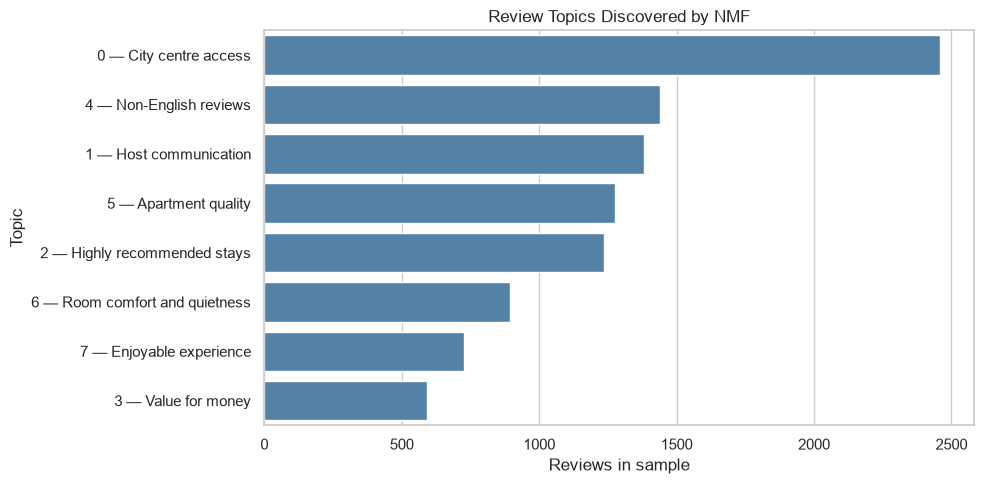

In [10]:
plot_df = topic_summary.copy()
plot_df["topic_label"] = plot_df["topic_id"].astype(str) + " — " + plot_df["interpreted_label"]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="reviews_in_sample", y="topic_label", color="steelblue")
plt.title("Review Topics Discovered by NMF")
plt.xlabel("Reviews in sample")
plt.ylabel("Topic")
plt.tight_layout()
plt.savefig(figures_dir / "12_review_topic_distribution.png", dpi=150)
plt.show()

### Business interpretation — topics

Recurring guest themes in Edinburgh reviews include:

- **Location and walkability** (city centre, close, easy access)
- **Host responsiveness and communication**
- **Cleanliness and comfort**
- **Value for money**
- **Overall recommendation language** (`highly recommend`, `perfect`, `amazing`)

For a consultancy, these themes can drive host coaching priorities and neighbourhood positioning.

## Step 6 — Save outputs for report/dashboard

In [11]:
sentiment_output = tables_dir / "review_sentiment_summary.csv"
correlation_output = tables_dir / "review_sentiment_rating_correlation.csv"
topic_output = tables_dir / "review_topic_summary.csv"

sentiment_df[["listing_id", "date", "comments", "polarity", "subjectivity", "sentiment_label"]].to_csv(
    sentiment_output,
    index=False,
)
correlation_summary.to_csv(correlation_output, index=False)
topic_summary.to_csv(topic_output, index=False)

print(f"Saved: {sentiment_output}")
print(f"Saved: {correlation_output}")
print(f"Saved: {topic_output}")

Saved: d:\Airbnb-Market-Intelligence\airbnb-market-intelligence-edinburgh\reports\tables\review_sentiment_summary.csv
Saved: d:\Airbnb-Market-Intelligence\airbnb-market-intelligence-edinburgh\reports\tables\review_sentiment_rating_correlation.csv
Saved: d:\Airbnb-Market-Intelligence\airbnb-market-intelligence-edinburgh\reports\tables\review_topic_summary.csv


## Section 07 Summary

This notebook completed the core NLP requirements:

- Loaded validated review comments from the pipeline
- Scored sentiment polarity and subjectivity with TextBlob
- Compared text sentiment with listing-level review ratings
- Discovered recurring guest themes using TF-IDF + NMF
- Saved outputs to `reports/tables/` and `reports/figures/`

---

## Interview cheat sheet (say this confidently)

1. **Problem:** Guest reviews are unstructured text; we need scalable insight.
2. **Approach:** Sentiment scoring + unsupervised topic modelling on sampled data.
3. **Data join logic:** Review text has no per-review stars, so we aggregated sentiment by listing and joined listing ratings.
4. **Trade-off:** TextBlob is interpretable and fast, but less advanced than transformer models.
5. **Business value:** Topics reveal what guests repeatedly care about (location, host, cleanliness, value).
6. **Next improvement:** Add language detection and multilingual models (e.g. VADER + language-specific pipelines).